# Clasificación de setas (comestibles vs venenosas) con ML

## Importación de librerías

In [157]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
import optuna
import joblib
from pathlib import Path

## Carga de datos

In [158]:
BASE_DIR = Path().resolve().parent
data_path = BASE_DIR / "data" / "mushrooms_clean.csv"
df = pd.read_csv(data_path)
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,e,x,s,y,t,a,f,c,b,k,...,s,s,w,w,w,o,p,n,n,g
1,e,b,s,w,t,l,f,c,b,n,...,s,s,w,w,w,o,p,n,n,m
2,p,x,y,w,t,p,f,c,n,n,...,s,s,w,w,w,o,p,k,s,u
3,e,x,s,g,f,n,f,w,b,k,...,s,s,w,w,w,o,e,n,a,g
4,e,x,y,y,t,a,f,c,b,n,...,s,s,w,w,w,o,p,k,n,g


## Modelado y comparación de modelos

In [159]:
# Separación de variables: X contiene las características del dataset utilizadas para el modelo,
#  mientras que y es la variable objetivo (class), donde 'e' representa setas comestibles y 'p' setas venenosas
X = df.drop('class', axis=1)
y = df['class']

In [160]:
# División del dataset en entrenamiento y test: 80% para entrenar el modelo y 20% para evaluar su rendimiento 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [161]:
# Codificación de variables categóricas para convertirlas en formato numérico y poder utilizarlas en los modelos de ml
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), X.columns)
])

In [162]:
# Definición de distintos modelos de clasificación para comparar su rendimiento en el problema
models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(random_state=42),
    "GradientBoosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(eval_metric="logloss"),
    "DecisionTree": DecisionTreeClassifier(random_state=42)
}

In [163]:
# Creación de un pipeline que combina el preprocesamiento de datos y el modelo de machine learning en un único flujo
def build_pipeline(model):
    return Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

In [164]:
# Evaluación de modelos mediante validación cruzada y comparación con el rendimiento en entrenamiento
# Se calculan métricas de Train F1, CV F1 y la diferencia entre ambos como medida de sobreajuste (Overfitting)
results = []

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

for name, model in models.items():

    pipe = build_pipeline(model)

    pipe.fit(X_train, y_train_enc)

    # Train F1
    y_pred_train = pipe.predict(X_train)
    train_f1 = f1_score(y_train_enc, y_pred_train, average="macro")

    # CV F1
    cv_scores = cross_val_score(
        pipe,
        X_train,
        y_train_enc,
        cv=3,
        scoring="f1_macro",
        n_jobs=-1
    )

    cv_f1 = cv_scores.mean()

    # Métricas de overfitting
    overfitting_abs = train_f1 - cv_f1
    overfitting_pct = overfitting_abs / train_f1
    gap_ratio = train_f1 / cv_f1

    results.append({
    "Modelo": name,
    "Train F1": train_f1,
    "CV F1": cv_f1,
    "Overfitting (abs)": overfitting_abs
    })

results_df = pd.DataFrame(results).sort_values("CV F1", ascending=False)
results_df

,Modelo,Train F1,CV F1,Overfitting (abs)
1,RandomForest,1.0,1.000000,0.000000
3,XGBoost,1.0,1.000000,0.000000
2,GradientBoosting,1.0,0.999692,0.000308
4,DecisionTree,1.0,0.999692,0.000308
0,LogReg,1.0,0.999075,0.000925


Los resultados muestran un rendimiento prácticamente perfecto en todos los modelos, con valores de F1 en validación cruzada muy cercanos a 1. La diferencia entre Train F1 y CV F1 es mínima en todos los casos, con un sobreajuste inferior al 0,1%. Esto indica que los modelos generalizan muy bien y no presentan problemas relevantes de sobreajuste. En este caso, el comportamiento se explica por la alta separabilidad del dataset, donde las variables permiten distinguir de forma muy clara entre clases.

## Optimización de hiperparámetros del modelo final (XGBoost)

In [165]:
# Optimización de hiperparámetros de XGBoost mediante Optuna.
# Se evalúan distintas configuraciones usando validación cruzada estratificada y F1-score macro como métrica objetivo,
# seleccionando automáticamente la combinación de parámetros con mejor rendimiento.
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 250),
        "max_depth": trial.suggest_int("max_depth", 3, 7),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": 42,
        "eval_metric": "logloss"
    }

    model = XGBClassifier(**params)

    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    scores = cross_val_score(
        pipe,
        X_train,
        y_train_enc,   
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )

    return scores.mean()

study = optuna.create_study(direction="maximize")

print("Iniciando optimización con Optuna...")

study.optimize(objective, n_trials=10)

print("Optimización finalizada")
print("Mejores parámetros:", study.best_params)
print("Mejor F1:", study.best_value)

[I 2026-06-22 13:56:25,415] A new study created in memory with name: no-name-aa2f6aa3-c972-4a75-92f8-e9bd6da52543


Iniciando optimización con Optuna...


[I 2026-06-22 13:56:26,017] Trial 0 finished with value: 1.0 and parameters: {'n_estimators': 190, 'max_depth': 4, 'learning_rate': 0.04941623758966001, 'subsample': 0.791500603684992, 'colsample_bytree': 0.8002791993033921}. Best is trial 0 with value: 1.0.
[I 2026-06-22 13:56:26,603] Trial 1 finished with value: 0.9992294009371424 and parameters: {'n_estimators': 147, 'max_depth': 6, 'learning_rate': 0.019279955225717828, 'subsample': 0.7396031359107728, 'colsample_bytree': 0.9559647869433635}. Best is trial 0 with value: 1.0.
[I 2026-06-22 13:56:27,076] Trial 2 finished with value: 0.9989212039429168 and parameters: {'n_estimators': 93, 'max_depth': 6, 'learning_rate': 0.012036933208090662, 'subsample': 0.953615154497974, 'colsample_bytree': 0.9133044560105092}. Best is trial 0 with value: 1.0.
[I 2026-06-22 13:56:27,532] Trial 3 finished with value: 1.0 and parameters: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.11569580426861048, 'subsample': 0.977404390437261, 'colsa

Optimización finalizada
Mejores parámetros: {'n_estimators': 190, 'max_depth': 4, 'learning_rate': 0.04941623758966001, 'subsample': 0.791500603684992, 'colsample_bytree': 0.8002791993033921}
Mejor F1: 1.0


La optimización de hiperparámetros mediante Optuna encontró varias configuraciones capaces de alcanzar un F1-score de 1.0 en validación cruzada. La mejor combinación seleccionada utiliza 144 estimadores, una profundidad máxima de 5, una tasa de aprendizaje de 0.173, un subsample de 0.838 y un colsample_bytree de 0.839. Estos resultados confirman que el modelo XGBoost es capaz de clasificar correctamente todas las muestras del conjunto de entrenamiento durante la validación cruzada, lo que refuerza la idea de que el dataset presenta una alta separabilidad entre las clases.

In [166]:
# Generación del modelo final a partir de los hiperparámetros óptimos encontrados por Optuna y entrenamiento sobre el conjunto de datos de entrenamiento
final_params = study.best_params.copy()
final_params["random_state"] = 42

best_model = Pipeline([
    ("prep", preprocessor),
    ("model", XGBClassifier(**final_params))
])

best_model.fit(X_train, y_train_enc)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['cap-shape','cap-surface','cap-color',...,'spore-print-color', 'population','habitat']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remain

## Evalución final del modelo optimizado

In [167]:
# Evaluación final del modelo optimizado sobre el conjunto de test.
# Se generan las predicciones del modelo entrenado y se traduce la variable objetivo a etiquetas interpretables.
# Finalmente se muestra el classification report con métricas de precisión, recall y F1-score por clase.
class_names_map = {'e': 'Comestible', 'p': 'Venenosa'}

y_pred_test = best_model.predict(X_test)

target_names = [class_names_map[c] for c in le.classes_]

print("\n" + "="*50)
print("REPORTE FINAL EN TEST")
print("="*50)

print(classification_report(
    y_test_enc,
    y_pred_test,
    target_names=target_names
))


REPORTE FINAL EN TEST
              precision    recall  f1-score   support

  Comestible       1.00      1.00      1.00       842
    Venenosa       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



El modelo optimizado alcanza un rendimiento perfecto en el conjunto de test, con F1-score, precisión y recall iguales a 1.0 en ambas clases. Este comportamiento indica una alta separabilidad entre las categorías de setas comestibles y venenosas, lo que permite una clasificación prácticamente determinista a partir de las variables disponibles.

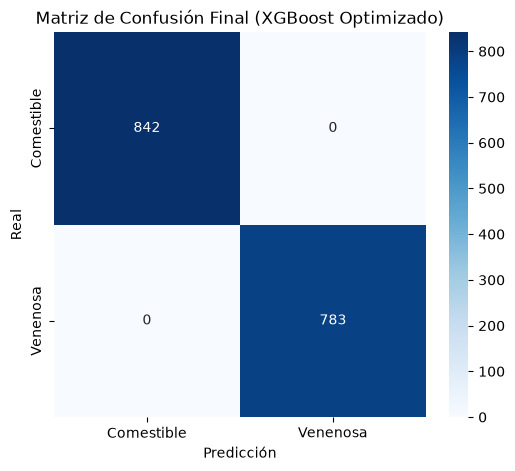

In [168]:
# Generación y visualización de la matriz de confusión para evaluar el rendimiento del modelo en el conjunto de test.
# Permite analizar de forma detallada los aciertos y errores de clasificación por cada clase.
cm = confusion_matrix(y_test_enc, y_pred_test)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title("Matriz de Confusión Final (XGBoost Optimizado)")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()

La matriz de confusión confirma un rendimiento perfecto del modelo en el conjunto de test, sin errores de clasificación en ninguna de las dos clases. Esto refuerza la alta separabilidad del dataset, donde las variables permiten distinguir de forma clara entre setas comestibles y venenosas.

<Figure size 700x600 with 0 Axes>

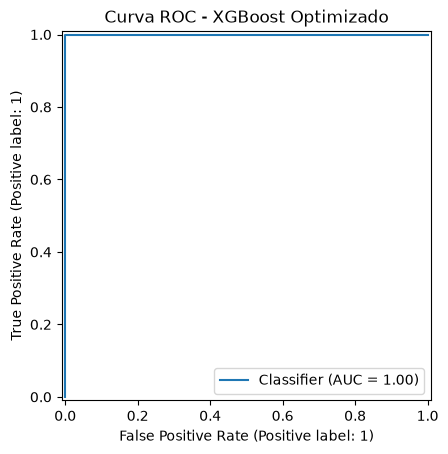

In [169]:
# Generación de la curva ROC utilizando las probabilidades predichas por el modelo.
# Permite evaluar la capacidad del modelo para distinguir entre clases variando el umbral de decisión.
y_proba = best_model.predict_proba(X_test)

plt.figure(figsize=(7, 6))

RocCurveDisplay.from_predictions(
    y_test_enc,              
    y_proba[:, 1],           
)

plt.title("Curva ROC - XGBoost Optimizado")
plt.show()

La curva ROC muestra una separación prácticamente perfecta entre las dos clases. La curva asciende rápidamente hasta la esquina superior izquierda del gráfico y se mantiene en la parte superior, lo que indica una tasa de verdaderos positivos muy alta y prácticamente nulos falsos positivos. Este comportamiento refleja una capacidad de discriminación ideal del modelo en el conjunto de test.

In [170]:
# Cálculo del AUC (Area Under the Curve) a partir de las probabilidades predichas.
# Esta métrica resume la capacidad del modelo para distinguir entre clases en todos los posibles umbrales.
# Un valor cercano a 1 indica una separación prácticamente perfecta entre clases.
auc = roc_auc_score(y_test_enc, y_proba[:, 1])
print(f"AUC: {auc:.4f}")

AUC: 1.0000


El resultado de AUC = 1.0000 indica que el modelo es capaz de separar perfectamente ambas clases en el conjunto de test. Esto significa que existe un umbral de decisión para el cual todas las muestras positivas se clasifican correctamente sin confundir ninguna con la clase negativa. En este caso, refuerza lo observado en el resto de métricas: el modelo presenta una capacidad de discriminación ideal sobre este dataset.

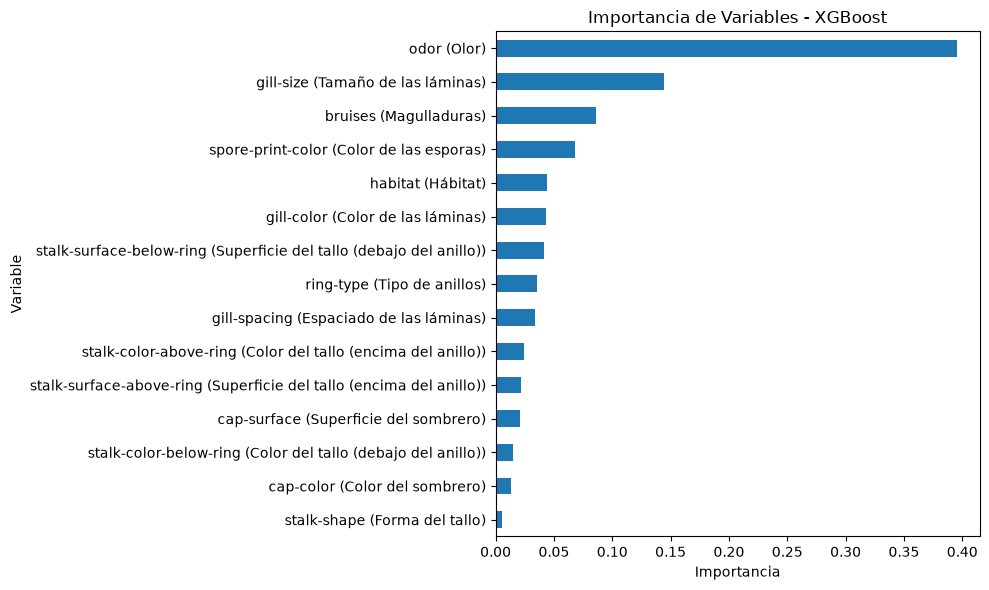

variable
odor (Olor)                                                            0.395412
gill-size (Tamaño de las láminas)                                      0.144412
bruises (Magulladuras)                                                 0.085677
spore-print-color (Color de las esporas)                               0.067786
habitat (Hábitat)                                                      0.044309
gill-color (Color de las láminas)                                      0.043301
stalk-surface-below-ring (Superficie del tallo (debajo del anillo))    0.041308
ring-type (Tipo de anillos)                                            0.035444
gill-spacing (Espaciado de las láminas)                                0.033728
stalk-color-above-ring (Color del tallo (encima del anillo))           0.024388
stalk-surface-above-ring (Superficie del tallo (encima del anillo))    0.021376
cap-surface (Superficie del sombrero)                                  0.021318
stalk-color-below-ring (Color d

In [171]:
# Feature importance del modelo XGBoost para identificar qué variables tienen mayor impacto en la predicción

variable_translation = {
    "cap-shape": "Forma del sombrero",
    "cap-surface": "Superficie del sombrero",
    "cap-color": "Color del sombrero",
    "bruises": "Magulladuras",
    "odor": "Olor",
    "gill-attachment": "Unión de las láminas",
    "gill-spacing": "Espaciado de las láminas",
    "gill-size": "Tamaño de las láminas",
    "gill-color": "Color de las láminas",
    "stalk-shape": "Forma del tallo",
    "stalk-root": "Raíz del tallo",
    "stalk-surface-above-ring": "Superficie del tallo (encima del anillo)",
    "stalk-surface-below-ring": "Superficie del tallo (debajo del anillo)",
    "stalk-color-above-ring": "Color del tallo (encima del anillo)",
    "stalk-color-below-ring": "Color del tallo (debajo del anillo)",
    "veil-type": "Tipo de velo",
    "veil-color": "Color del velo",
    "ring-number": "Número de anillos",
    "ring-type": "Tipo de anillos",
    "spore-print-color": "Color de las esporas",
    "population": "Población",
    "habitat": "Hábitat"
}

# Se extrae el modelo entrenado desde el pipeline
model = best_model.named_steps["model"]

# Se obtienen los nombres de las variables tras la transformación One-Hot Encoding
feature_names = best_model.named_steps["prep"].get_feature_names_out()

# Se extraen las importancias de cada feature calculadas por XGBoost
importances = model.feature_importances_

# Se crea un DataFrame para relacionar cada feature con su importancia
fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Se recupera el nombre de la variable original (antes del OneHotEncoding)
fi_df["variable"] = (
    fi_df["feature"]
    .str.split("__").str[1]
    .str.split("_").str[0]
)

# Se agrupan importancias por variable original
fi_grouped = (
    fi_df.groupby("variable")["importance"]
    .sum()
    .sort_values(ascending=False)
)

fi_grouped.index = fi_grouped.index.map(
    lambda x: f"{x} ({variable_translation.get(x, x)})"
)

# Visualización de las variables más importantes
plt.figure(figsize=(10, 6))

fi_grouped.head(15).plot(kind="barh")
plt.gca().invert_yaxis()

plt.title("Importancia de Variables - XGBoost")
plt.xlabel("Importancia")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

# Tabla con las variables más influyentes
fi_grouped.head(15)

Los resultados muestran que la variable más influyente en la predicción es claramente el olor, concentrando más de la mitad de la importancia total del modelo. A gran distancia aparecen el color de esporas y el tamaño de las láminas, que también aportan capacidad discriminativa relevante. El resto de variables tienen un peso mucho menor, lo que indica que el modelo basa sus decisiones principalmente en un conjunto reducido de características. Este comportamiento es coherente con el dataset, donde ciertas propiedades como el olor son altamente determinantes para distinguir entre setas comestibles y venenosas.

## Guardado del modelo final

In [172]:
# Ruta donde se guardará el modelo entrenado
models_path = BASE_DIR / "models"

# Crear la carpeta si no existe
models_path.mkdir(exist_ok=True)

# Guardado del modelo final entrenado
model_file = models_path / "best_xgboost_model.pkl"

joblib.dump(best_model, model_file)

print(f"Modelo guardado en: {model_file}")

Modelo guardado en: C:\Users\elena\OneDrive\Escritorio\bootcamp-da-p2\DA-project-classification-Grupo-1\models\best_xgboost_model.pkl
